# Summary Scores

## Imports

In [2]:
import torch
import pandas as pd
import evaluate
from tqdm import tqdm
from datasets import Dataset
from rouge_score import rouge_scorer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

/opt/miniconda3/envs/bart_env_312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Models

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bart_id = "facebook/bart-large-cnn"
model_40k_id = "Veekee/cmpe-252-summary-project"
model_15k_id = "../models/checkpoint-11619"

bart_tokenizer = AutoTokenizer.from_pretrained(bart_id)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(bart_id).to(device)

model_40k_tokenizer = AutoTokenizer.from_pretrained(model_40k_id)
model_40k_model = AutoModelForSeq2SeqLM.from_pretrained(model_40k_id).to(device)

model_15k_tokenizer = AutoTokenizer.from_pretrained(model_15k_id)
model_15k_model = AutoModelForSeq2SeqLM.from_pretrained(model_15k_id).to(device)

model_15k_tokenizer = AutoTokenizer.from_pretrained(model_15k_id)
model_15k_model = AutoModelForSeq2SeqLM.from_pretrained(model_15k_id).to(device)

Loading weights: 100%|██████████| 511/511 [00:00<00:00, 1183.27it/s, Materializing param=model.encoder.layers.11.self_attn_layer_norm.weight]   
BartForConditionalGeneration LOAD REPORT from: facebook/bart-large-cnn
Key                               | Status  | 
----------------------------------+---------+-
lm_head.weight                    | MISSING | 
final_logits_bias                 | MISSING | 
model.shared.weight               | MISSING | 
model.encoder.embed_tokens.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


KeyboardInterrupt: 

## Upload Test Dataset

In [8]:
test_df = pd.read_parquet("../data/test_data.parquet")

test_dataset = Dataset.from_pandas(test_df)

## Get Table of Generated Summaries

In [3]:
model_summaries_df = pd.read_csv("../data/models_summaries_table_arxiv.csv")
model_summaries_dataset = Dataset.from_pandas(model_summaries_df)


## Generate Summary

In [ ]:
def generate_summary(text, model, tokenizer):  
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)

    with torch.no_grad():
        summary_ids = model.generate(
            inputs["input_ids"],
            num_beams=4,
            max_length=128,
            min_length=30,
            no_repeat_ngram_size=3, # prevents loops
            length_penalty=2.0,     # standard penalty
            early_stopping=True
        )

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

## Generate Summary and Score Summaries

Each model generates their summaries and scores based on each summary compared to the reference

In [ ]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
results = []

for sample in tqdm(test_dataset.select(range(5))):
    source = sample['article']
    reference = sample['abstract']

    bart_summary = generate_summary(source, bart_model, bart_tokenizer)
    model_40k_summary = generate_summary(source, model_40k_model, model_40k_tokenizer)
    model_15k_summary = generate_summary(source, model_15k_model, model_15k_tokenizer)

    bart_scores = scorer.score(reference, bart_summary)
    model_40k_scores = scorer.score(reference, model_40k_summary)
    model_15k_scores = scorer.score(reference, model_15k_summary)

    bart_cr = len(bart_summary.split()) / len(source.split())
    model_40k_cr = len(model_40k_summary.split()) / len(source.split())
    model_15k_cr = len(model_15k_summary.split()) / len(source.split())

    bart_density = bart_scores['rougeL'].fmeasure / (bart_cr + 1e-9)
    model_40k_density = model_40k_scores['rougeL'].fmeasure / (model_40k_cr + 1e-9)
    model_15k_density = model_15k_scores['rougeL'].fmeasure / (model_15k_cr + 1e-9)

    results.append({
        "bart_summary": bart_summary,
        "model_40k_summary": model_40k_summary,
        "model_15k_summary": model_15k_summary,
        "bart_r1": bart_scores['rouge1'].fmeasure,
        "model_40k_r1": model_40k_scores['rouge1'].fmeasure,
        "model_15k_r1": model_15k_scores['rouge1'].fmeasure,
        "bart_r2": bart_scores['rouge2'].fmeasure,
        "model_40k_r2": model_40k_scores['rouge2'].fmeasure,
        "model_15k_r2": model_15k_scores['rouge2'].fmeasure,
        "bart_rL": bart_scores['rougeL'].fmeasure,
        "model_40k_rL": model_40k_scores['rougeL'].fmeasure,
        "model_15k_rL": model_15k_scores['rougeL'].fmeasure,
        "bart_cr": bart_cr,
        "model_40k_cr": model_40k_cr,
        "model_15k_cr": model_15k_cr,
        "bart_density": bart_density,
        "model_40k_density": model_40k_density,
        "model_15k_density": model_15k_density
    })

df_results = pd.DataFrame(results)
df_results.head()

100%|██████████| 5/5 [03:34<00:00, 42.88s/it]


,bart_summary,model1_summary,model2_summary,bart_r1,model1_r1,model2_r1,bart_r2,model1_r2,model2_r2,bart_rL,model1_rL,model2_rL,bart_cr,model1_cr,model2_cr,bart_density,model1_density,model2_density
0,The problem of properties of short - term chan...,a new method of the diagnosis of an echo - eff...,we present a new approach to the problem of th...,0.281250,0.418118,0.392027,0.102362,0.175439,0.127090,0.179688,0.236934,0.199336,0.010285,0.018341,0.019026,17.471613,12.918427,10.476789
1,It is believed that the direct detection of gr...,we investigate the detectability of circular p...,we investigate the detectability of circular p...,0.358209,0.473988,0.500000,0.136364,0.269006,0.252874,0.253731,0.404624,0.375000,0.007049,0.014710,0.015170,35.996750,27.506019,24.719695
2,The tunneling through a potential barrier play...,a new formula for the barrier penetrability of...,we have derived a new barrier penetration form...,0.285714,0.596273,0.571429,0.057971,0.389937,0.366667,0.214286,0.447205,0.318681,0.023762,0.032622,0.043496,9.018159,13.708764,7.326719
3,The hybrid monte carlo algorithm ( hmc)@xcite ...,we present a new class of numerical time integ...,we study the behavior of numerical time integr...,0.559524,0.543210,0.441860,0.156627,0.175000,0.141176,0.226190,0.296296,0.267442,0.027360,0.027360,0.029822,8.267262,10.829629,8.967890
4,In the present paper we propose essentially ne...,in this paper we propose essentially new metho...,we propose essentially new methods for derivin...,0.304878,0.391753,0.405797,0.098765,0.166667,0.136585,0.182927,0.257732,0.241546,0.012318,0.020381,0.023516,14.850331,12.645859,10.271451


## Score Existing Summaries Table

In [5]:
r_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
bert_scorer = evaluate.load("bertscore")

results = []

for sample in tqdm(model_summaries_dataset):
    source = sample['Source']
    reference = sample['Reference']

    bart_summary = sample['BART Summary']
    t5_summary = sample['T5 Summary']
    model_40k_summary = sample['Model 40k Summary']
    model_15k_summary = sample['Model 15k Summary']

    bart_scores = r_scorer.score(reference, bart_summary)
    t5_scores = r_scorer.score(reference, t5_summary)
    model_40k_scores = r_scorer.score(reference, model_40k_summary)
    model_15k_scores = r_scorer.score(reference, model_15k_summary)

    bart_bertscore = bert_scorer.compute(predictions=[bart_summary], references=[reference], lang="en")
    t5_bertscore = bert_scorer.compute(predictions=[t5_summary], references=[reference], lang="en")
    model_40k_bertscore = bert_scorer.compute(predictions=[model_40k_summary], references=[reference], lang="en")
    model_15k_bertscore = bert_scorer.compute(predictions=[model_15k_summary], references=[reference], lang="en")

    bart_cr = len(bart_summary.split()) / len(source.split())
    t5_cr = len(t5_summary.split()) / len(source.split())
    model_40k_cr = len(model_40k_summary.split()) / len(source.split())
    model_15k_cr = len(model_15k_summary.split()) / len(source.split())

    bart_density = bart_scores['rougeL'].fmeasure / (bart_cr + 1e-9)
    t5_density = t5_scores['rougeL'].fmeasure / (t5_cr + 1e-9)
    model_40k_density = model_40k_scores['rougeL'].fmeasure / (model_40k_cr + 1e-9)
    model_15k_density = model_15k_scores['rougeL'].fmeasure / (model_15k_cr + 1e-9)

    results.append({
        "bart_summary": bart_summary,
        "t5_summary": t5_summary,
        "model_40k_summary": model_40k_summary,
        "model_15k_summary": model_15k_summary,
        "bart_r1": bart_scores['rouge1'].fmeasure,
        "t5_r1": t5_scores['rouge1'].fmeasure,
        "model_40k_r1": model_40k_scores['rouge1'].fmeasure,
        "model_15k_r1": model_15k_scores['rouge1'].fmeasure,
        "bart_r2": bart_scores['rouge2'].fmeasure,
        "t5_r2": t5_scores['rouge2'].fmeasure,
        "model_40k_r2": model_40k_scores['rouge2'].fmeasure,
        "model_15k_r2": model_15k_scores['rouge2'].fmeasure,
        "bart_rL": bart_scores['rougeL'].fmeasure,
        "t5_rL": t5_scores['rougeL'].fmeasure,
        "model_40k_rL": model_40k_scores['rougeL'].fmeasure,
        "model_15k_rL": model_15k_scores['rougeL'].fmeasure,
        "bart_cr": bart_cr,
        "t5_cr": t5_cr,
        "model_40k_cr": model_40k_cr,
        "model_15k_cr": model_15k_cr,
        "bart_density": bart_density,
        "t5_density": t5_density,
        "model_40k_density": model_40k_density,
        "model_15k_density": model_15k_density
    })

df_results = pd.DataFrame(results)
df_results.head()

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 531.51it/s, Materializing param=encoder.layer.23.output.dense.weight]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 6440/6440 [1:58:11<00:00,  1.10s/it]  


,bart_summary,t5_summary,model_40k_summary,model_15k_summary,bart_r1,t5_r1,model_40k_r1,model_15k_r1,bart_r2,t5_r2,...,model_40k_rL,model_15k_rL,bart_cr,t5_cr,model_40k_cr,model_15k_cr,bart_density,t5_density,model_40k_density,model_15k_density
0,The problem of properties of short - term chan...,the periodicities about 150160 days and from t...,a new method of the diagnosis of an echo - eff...,the existence of the 156-day periodicity in th...,0.281250,0.231405,0.418118,0.346939,0.102362,0.083333,...,0.236934,0.204082,0.010285,0.009085,0.018341,0.016969,17.471613,20.013720,12.918427,12.026386
1,It is believed that the direct detection of gr...,"in this paper , we investigate the detectabili...",we investigate the detectability of circular p...,we investigate the detectability of circular p...,0.358209,0.313433,0.473988,0.500000,0.136364,0.121212,...,0.404624,0.375000,0.007049,0.007508,0.014710,0.015323,35.996750,29.817236,27.506019,24.472498
2,The tunneling through a potential barrier play...,". in the appendix , the detailed derivation of...",a new formula for the barrier penetrability of...,we have derived a new barrier penetration form...,0.285714,0.446154,0.596273,0.550562,0.057971,0.187500,...,0.447205,0.292135,0.023762,0.022151,0.032622,0.042288,9.018159,13.890908,13.708764,6.908293
3,The hybrid monte carlo algorithm ( hmc)@xcite ...,the hybrid monte carlo algorithm ( hmc)@xcite ...,we present a new class of numerical time integ...,we study the behavior of numerical time integr...,0.559524,0.481752,0.543210,0.453488,0.156627,0.177778,...,0.296296,0.255814,0.027360,0.019699,0.027360,0.029822,8.267262,14.080494,10.829629,8.577981
4,In the present paper we propose essentially ne...,functional equation for the one - loop vertex ...,in this paper we propose essentially new metho...,we propose essentially new methods for derivin...,0.304878,0.284091,0.391753,0.388626,0.098765,0.034483,...,0.257732,0.236967,0.012318,0.017469,0.020381,0.025084,14.850331,9.757430,12.645859,9.446936


## Create Table to Compare All Scores

In [6]:
comparison_table = df_results[["bart_r1","bart_r2","bart_rL", "t5_r1", "t5_r2", "t5_rL","model_40k_r1","model_40k_r2","model_40k_rL","model_15k_r1","model_15k_r2","model_15k_rL","bart_cr","t5_cr","model_40k_cr","model_15k_cr","bart_density","t5_density","model_40k_density","model_15k_density"]].mean().to_frame(name="Average Scores")

display(comparison_table)

,Average Scores
bart_r1,0.308645
bart_r2,0.092282
bart_rL,0.180946
t5_r1,0.284459
t5_r2,0.083796
t5_rL,0.170776
model_40k_r1,0.411399
model_40k_r2,0.154089
model_40k_rL,0.239033
model_15k_r1,0.400663


## Save Score Results

In [7]:
results_parquet_path = "../results/all_results.parquet"
df_results.to_parquet(results_parquet_path, index=False)

comparison_parquet_path = "../results/comparison_table.parquet"
comparison_table.to_parquet(comparison_parquet_path)

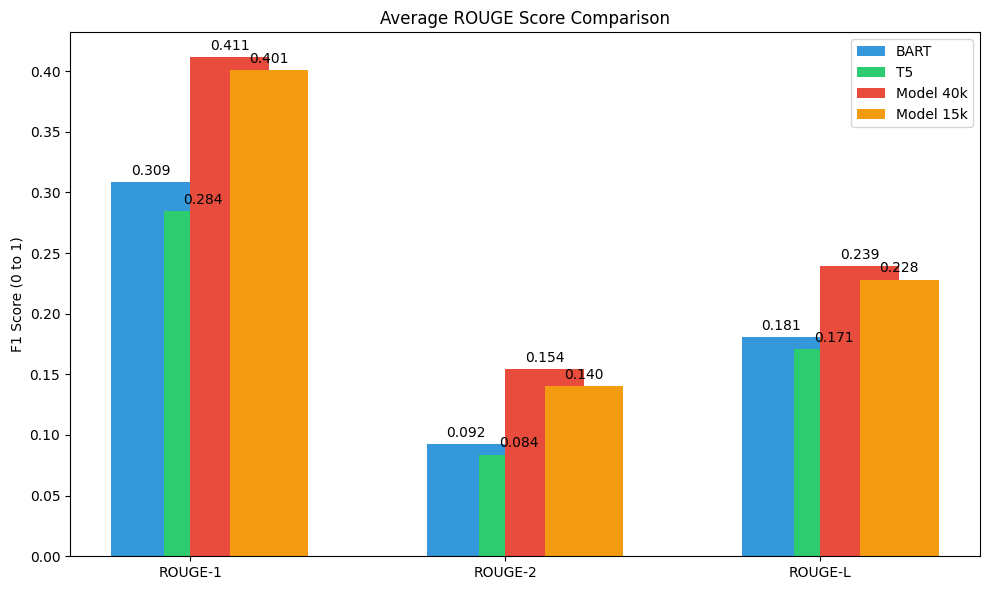

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate averages for all metrics
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
bart_means = [
    df_results['bart_r1'].mean(), 
    df_results['bart_r2'].mean(), 
    df_results['bart_rL'].mean()
]
t5_means = [
    df_results['t5_r1'].mean(), 
    df_results['t5_r2'].mean(), 
    df_results['t5_rL'].mean()
]
model_40k_means = [
    df_results['model_40k_r1'].mean(), 
    df_results['model_40k_r2'].mean(), 
    df_results['model_40k_rL'].mean()
]
model_15k_means = [
    df_results['model_15k_r1'].mean(), 
    df_results['model_15k_r2'].mean(), 
    df_results['model_15k_rL'].mean()
]

# 2. Set up the bar locations
x = np.arange(len(metrics))
width = 1 / 4

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, bart_means, width, label='BART', color='#3498db')
rects2 = ax.bar(x + width/6, t5_means, width, label='T5', color='#2ecc71')
rects3 = ax.bar(x + width/2, model_40k_means, width, label='Model 40k', color='#e74c3c')
rects4 = ax.bar(x + width, model_15k_means, width, label='Model 15k', color='#f39c12')

# 4. Add labels and styling
ax.set_ylabel('F1 Score (0 to 1)')
ax.set_title('Average ROUGE Score Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# 5. Add text labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.savefig('../results/rouge_comparison_chart.png')
plt.show()

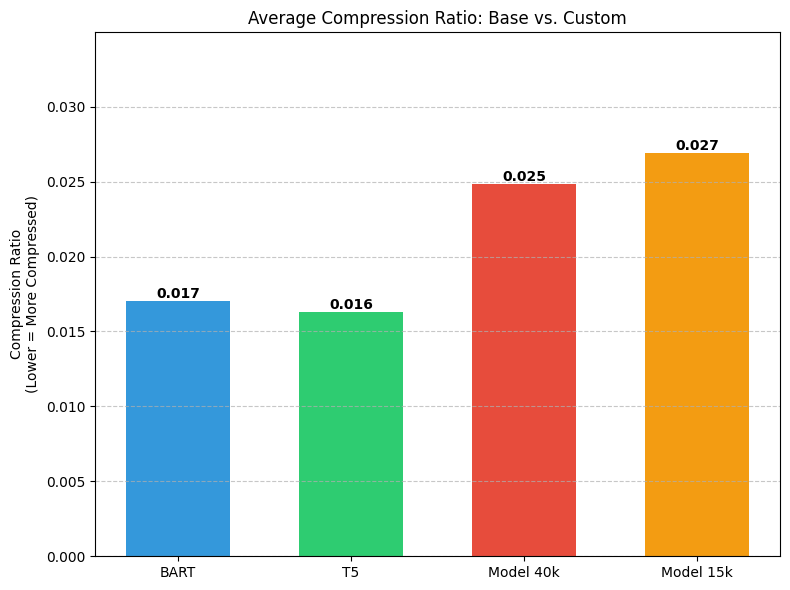

In [15]:
import matplotlib.pyplot as plt

# 1. Calculate the means
bart_cr_mean = df_results['bart_cr'].mean()
t5_cr_mean = df_results['t5_cr'].mean()
model_40k_cr_mean = df_results['model_40k_cr'].mean()
model_15k_cr_mean = df_results['model_15k_cr'].mean()

# 2. Create the Bar Chart
plt.figure(figsize=(8, 6))
models = ['BART', 'T5', 'Model 40k', 'Model 15k']
means = [bart_cr_mean, t5_cr_mean, model_40k_cr_mean, model_15k_cr_mean]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = plt.bar(models, means, color=colors, width=0.6)

# 3. Add Labels and Styling
plt.ylabel('Compression Ratio\n(Lower = More Compressed)')
plt.title('Average Compression Ratio: Base vs. Custom')
plt.ylim(0, max(means) * 1.3) # Add space for labels

# Add the values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../results/compression_ratio_comparison_chart.png')
plt.show()

/var/folders/60/b5613ft91lj31zhgk9phb9hr0000gn/T/ipykernel_2834/3600006981.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Compression Ratio', data=plot_df, palette=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])


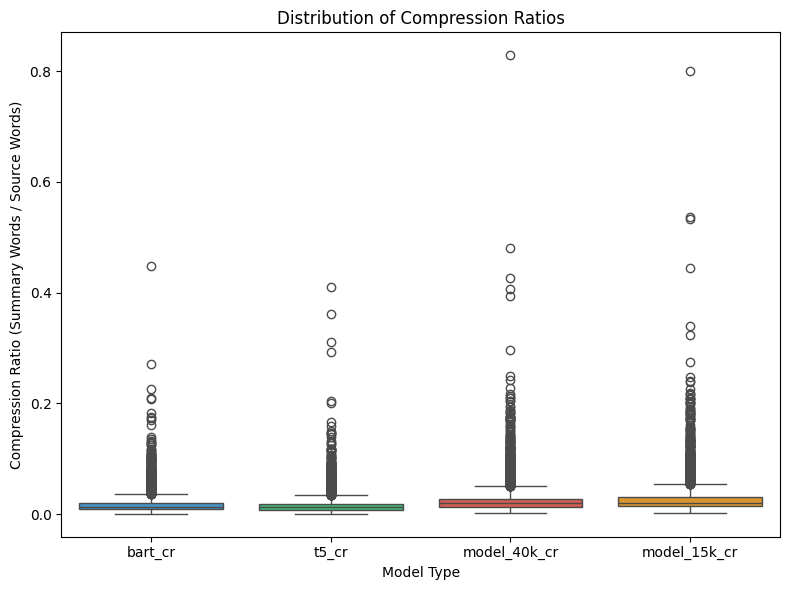

In [16]:
import seaborn as sns

# 1. Prepare data for Seaborn (Long format)
plot_df = df_results.melt(value_vars=['bart_cr', 't5_cr', 'model_40k_cr', 'model_15k_cr'], 
                          var_name='Model', 
                          value_name='Compression Ratio')

# 2. Create the Box Plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Model', y='Compression Ratio', data=plot_df, palette=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])

# 3. Add Labels
plt.title('Distribution of Compression Ratios')
plt.ylabel('Compression Ratio (Summary Words / Source Words)')
plt.xlabel('Model Type')

plt.tight_layout()
plt.savefig('../results/compression_distribution_box.png')
plt.show()

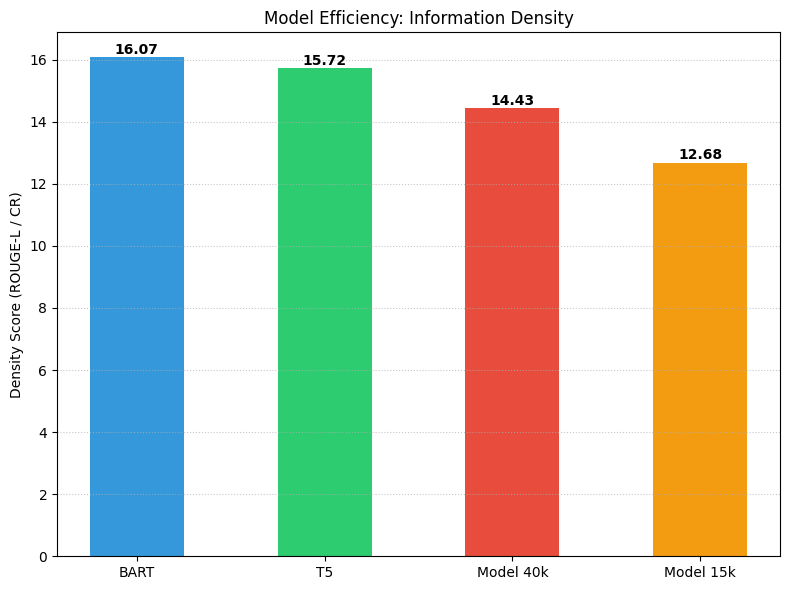

In [17]:
# 1. Calculate the mean density
bart_density_mean = df_results['bart_density'].mean()
t5_density_mean = df_results['t5_density'].mean()
model_40k_density_mean = df_results['model_40k_density'].mean()
model_15k_density_mean = df_results['model_15k_density'].mean()

# 2. Plotting
plt.figure(figsize=(8, 6))
labels = ['BART', 'T5', 'Model 40k', 'Model 15k']
densities = [bart_density_mean, t5_density_mean, model_40k_density_mean, model_15k_density_mean]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = plt.bar(labels, densities, color=colors, width=0.5)

# 3. Styling
plt.ylabel('Density Score (ROUGE-L / CR)')
plt.title('Model Efficiency: Information Density')
plt.grid(axis='y', linestyle=':', alpha=0.7)

# Add numeric labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/information_density_comparison_chart.png')
plt.show()

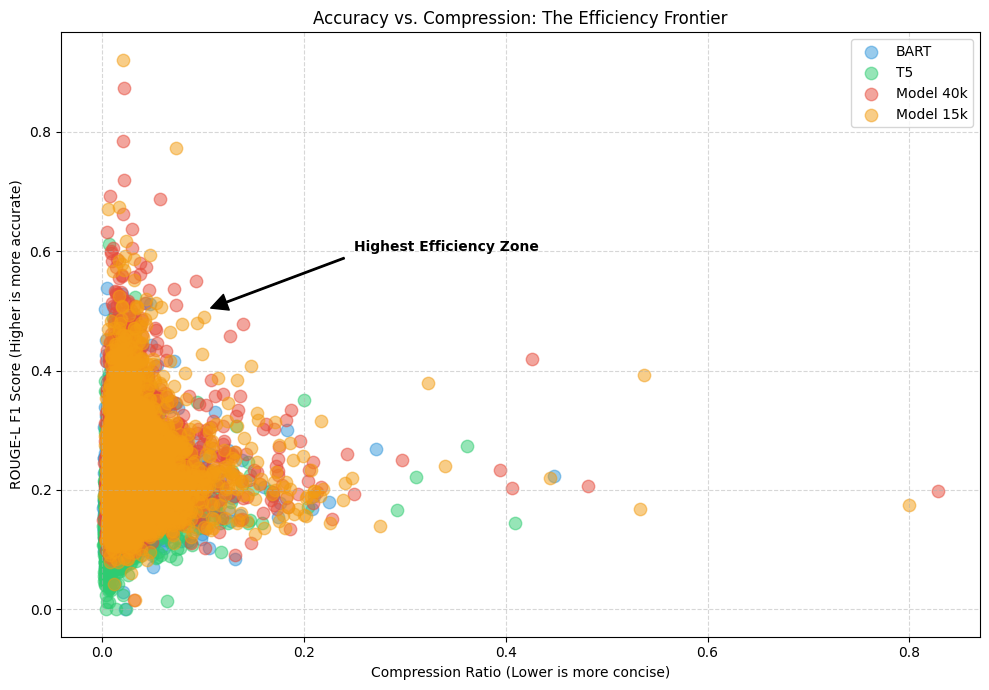

In [18]:
plt.figure(figsize=(10, 7))

# Plot Base Model samples
plt.scatter(df_results['bart_cr'], df_results['bart_rL'], 
            alpha=0.5, label='BART', color='#3498db', s=80)

# Plot Custom Model samples
plt.scatter(df_results['t5_cr'], df_results['t5_rL'], 
            alpha=0.5, label='T5', color='#2ecc71', s=80)

plt.scatter(df_results['model_40k_cr'], df_results['model_40k_rL'], 
            alpha=0.5, label='Model 40k', color='#e74c3c', s=80)

plt.scatter(df_results['model_15k_cr'], df_results['model_15k_rL'], 
            alpha=0.5, label='Model 15k', color='#f39c12', s=80)

# Add "Target Zone" Annotation
plt.annotate('Highest Efficiency Zone', xy=(0.1, 0.5), xytext=(0.25, 0.6),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=10, fontweight='bold')

# Styling
plt.xlabel('Compression Ratio (Lower is more concise)')
plt.ylabel('ROUGE-L F1 Score (Higher is more accurate)')
plt.title('Accuracy vs. Compression: The Efficiency Frontier')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../results/accuracy_compression_scatter.png')
plt.show()